In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.nn.utils.parametrizations import weight_norm
from torch.utils.data import DataLoader, TensorDataset, random_split
from matplotlib import pyplot as plt
from tqdm import tqdm
import sys, os
sys.path.append(os.path.abspath("../../lib"))
import util
import importlib
importlib.reload(util)

<module 'util' from 'C:\\Users\\amand\\Documents\\Research\\Project_LIDI\\VAE_Tutorials\\lib\\util.py'>

# Introduction

Because the iVAE dataset is quite different from MNIST, applying LVAE to this dataset can reveal interesting properties about how the architecture must be adjusted to smaller datasets. The first comparison is how the LVAE model used on MNIST performs on iVAE data. The second comparison is LVAE fine-tuned to iVAE data using similar parameter values to iVAE.

### MLP network

In [2]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden, **kwargs):
        super().__init__()
        
        slope = 0.01
        num_layers = kwargs.get('num_layers', 2)  # number of (linear, activation) blocks before output
        norm_type = kwargs.get('norm_type')

        hidden_dims = [in_dim] + num_layers * [hidden]

        # Define middle layers
        layer_lst = []
        for n in range(num_layers):
            # Linear layer (+ normalization)
            if norm_type == 'none':
                layer_lst.append(nn.Linear(hidden_dims[n], hidden_dims[n + 1]))
            elif norm_type == 'weight':
                layer_lst.append(weight_norm(nn.Linear(hidden_dims[n], hidden_dims[n + 1])))
            elif norm_type == 'batch':
                layer_lst.append(nn.Linear(hidden_dims[n], hidden_dims[n + 1]))
                layer_lst.append(nn.BatchNorm1d(hidden_dims[n+1]))
            elif norm_type == 'batch_weight':
                layer_lst.append(weight_norm(nn.Linear(hidden_dims[n], hidden_dims[n + 1])))
                layer_lst.append(nn.BatchNorm1d(hidden_dims[n + 1]))

        self.layers = nn.Sequential(*layer_lst)

        # Define output layers
        self.mu = nn.Linear(hidden_dims[-1], out_dim)
        self.log_var = nn.Linear(hidden_dims[-1], out_dim)

    def forward(self, x, return_intermed=False):
        out = self.layers(x)

        output = []
        if return_intermed:
            output.append(out)
        output.append(self.mu(out))
        output.append(self.log_var(out))
        return output

### LVAE model

In [3]:
class LVAE(nn.Module):
    def __init__(self, kx, **kwargs):
        super().__init__()

        self.kx = kx

        # Default values are for original iVAE
        self.pz = kwargs.get('pz')
        self.num_hier = len(self.pz)  # number of hierarchical layers, must be at least 2
        self.hidden_dim = kwargs.get('hidden_dim')
        self.n_warmup = kwargs.get('n_warmup')  # number of epochs for KL loss annealing

        self.encoders = nn.ParameterList()
        self.decoders = nn.ParameterList()

        self.encoders.append(MLP(self.kx, self.pz[0], self.hidden_dim[0], **kwargs))
        for i in range(1, self.num_hier):
            mlp_enc = MLP(self.hidden_dim[i - 1], self.pz[i], self.hidden_dim[i], **kwargs)
            self.encoders.append(mlp_enc)
            mlp_dec = MLP(self.pz[self.num_hier-i], self.pz[self.num_hier-i-1], self.hidden_dim[-i], **kwargs)
            self.decoders.append(mlp_dec)
        self.decoders.append(MLP(self.pz[0], self.kx, self.hidden_dim[0], **kwargs))

    def forward(self, x):
        # hat = deterministic encoder layer, qs = stochastic encoder layer, ps = decoder layer
        mu_hats, mu_qs, mu_ps = [], [], []
        logvar_hats, logvar_qs, logvar_ps = [], [], []

        # === Encoder pass
        val = x
        for i in range(self.num_hier):
            val, mu_i_hat, logvar_i_hat = self.encoders[i](val, return_intermed=True)
            mu_hats.append(mu_i_hat)
            logvar_hats.append(logvar_i_hat)

        # === Reparameterization (last layer only)
        self.z = []
        z_val = util.sample(mu_hats[-1], logvar_hats[-1])
        self.z.append(z_val)

        # === Decoder pass
        # Add q(z_L|x)
        mu_qs.append(mu_hats[-1])
        logvar_qs.append(logvar_hats[-1])
        # Add prior p(z_L) ~ N(0, I)
        mu_ps.append(torch.zeros_like(z_val))
        logvar_ps.append(torch.zeros_like(z_val))

        for i in range(self.num_hier):
            # Get p(z_i|z_i+1) or p(x|z_1)
            mu_p, logvar_p = self.decoders[i](z_val)
            mu_ps.append(mu_p)
            logvar_ps.append(logvar_p)

            if i < self.num_hier-1:
                # Construct compound distribution
                idx = self.num_hier - i - 2  # iterate backwards on (mu_hat, logvar_hat), exclude first set outside loop
                mu_q, logvar_q = util.compound_normal(mu_hats[idx], logvar_hats[idx], mu_p, logvar_p)
                mu_qs.append(mu_q)
                logvar_qs.append(logvar_q)
                # Sample
                z_val = util.sample(mu_q, logvar_q)
                self.z.append(z_val)

        return mu_hats, logvar_hats, mu_qs, logvar_qs, mu_ps, logvar_ps

    def loss(self, x, params, beta=1):
        mu_hats, logvar_hats, mu_qs, logvar_qs, mu_ps, logvar_ps = params

        recon = -1 * util.normal_ll(x, mu_ps[-1], logvar_ps[-1])
        kl_div = 0
        kl_per_hier = []
        for i in range(self.num_hier):
            kl = util.kl_normal(mu_qs[i], logvar_qs[i], mu_ps[i], logvar_ps[i])
            kl_per_hier.append(kl.mean())
            kl_div += kl
        return recon.mean(), beta * kl_div.mean(), kl_per_hier

    def anneal(self, iteration):
        if self.n_warmup <= 0:
            return 1
        beta = np.min([iteration / self.n_warmup, 1])
        return beta

    def get_z_samples(self):
        return self.z

### Prepare for training

In [4]:
# Load CPU or GPU
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using CUDA")
else:
    device = torch.device("cpu")
    print("Using CPU")

Using CUDA


In [5]:
# Training & model settings
cfg = {
    'rng': 1,
    'batch_size': 256,
    'epochs': 20,
    'lr': 0.0001,
    'n_warmup': 2,
    'data_src': 'ivae1',
    'norm_type': 'batch',
    'pz': [64, 32, 16],
    'hidden_dim': [256, 128, 64]
}

# Set random seed
torch.manual_seed(cfg['rng'])
np.random.seed(cfg['rng'])

# Investigation 1: Baseline LVAE applied to iVAE data
We use approximately the same network as the baseline defined in chapter 1 for MNIST.

In [6]:
# Load iVAE dataset
data, kx = util.get_dataset(**cfg)
generator = torch.Generator().manual_seed(cfg['rng'])
train_data, valid_data, test_data = random_split(data, [0.8, 0.1, 0.1], generator=generator)
train_loader = DataLoader(train_data, cfg['batch_size'], shuffle=True)
test_loader = DataLoader(test_data, batch_size=len(test_data))

### Training

In [7]:
model_1 = LVAE(kx, **cfg).to(device)
optimizer = torch.optim.Adam(params=model_1.parameters(), lr=cfg['lr'])
util.get_num_parameters(model_1)

recon_1, kl_1, kl_hier_1, metrics_1 = util.train_lvae(model_1, optimizer, train_loader, device, **cfg)

Number of parameters: 306856


100%|██████████| 20/20 [00:33<00:00,  1.65s/it]


### Plot overall training loss

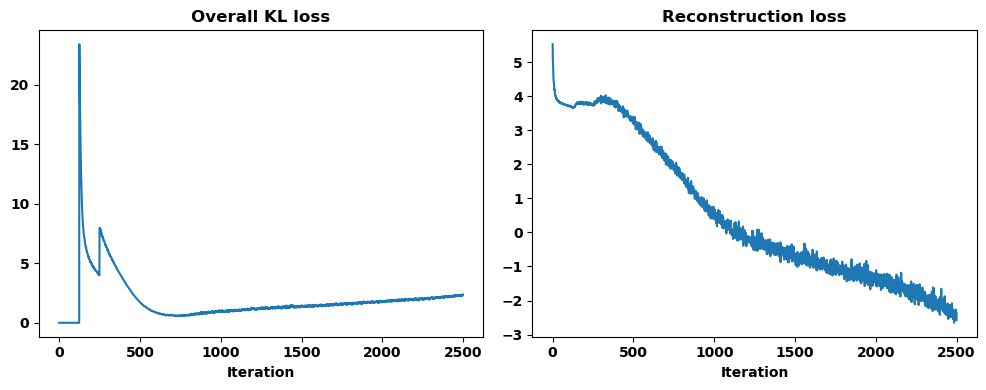

In [8]:
fig, axs = plt.subplots(nrows=1, ncols=2, sharex=True, figsize=(10, 4))

# Overall KL loss
axs[0].plot(kl_1)
axs[0].set_xlabel("Iteration")
axs[0].set_title("Overall KL loss")
# Reconstruction loss
axs[1].plot(recon_1)
axs[1].set_xlabel("Iteration")
axs[1].set_title("Reconstruction loss")
plt.tight_layout()

### Plot KL loss per hierarchy

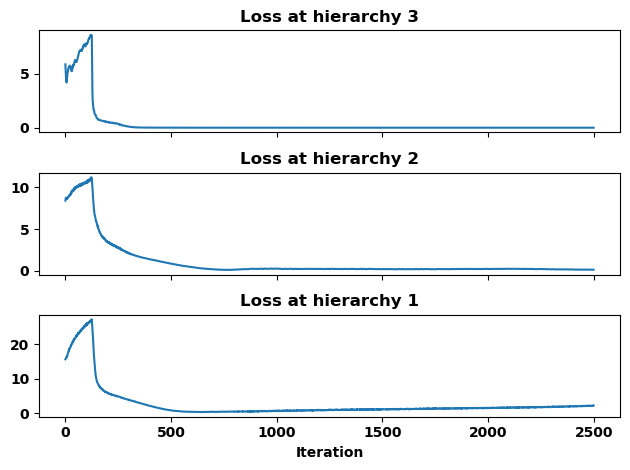

In [9]:
num_hier = kl_hier_1.shape[1]
fig, axs = plt.subplots(nrows=num_hier, ncols=1, sharex=True)

for i in range(num_hier):
    axs[i].plot(kl_hier_1[:, i], label="Level "+str(i))
    axs[i].set_title("Loss at hierarchy " + str(num_hier-i))
axs[i].set_xlabel("Iteration")
plt.tight_layout()

### Plot 2d PCA representation per hierarchy

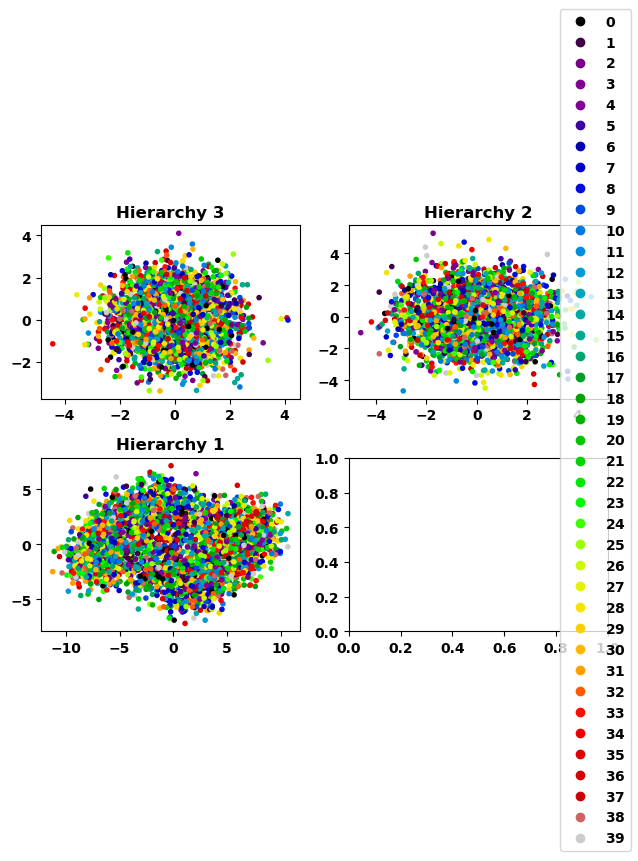

In [10]:
model_1.eval()
with torch.no_grad():
    for batch in test_loader:
        x, u = util.get_batch(batch, cfg['data_src'], device)
        output = model_1(x)
        
lbls = np.where(u.detach().cpu().numpy())[1]
zs = model_1.get_z_samples()
titles = ["Hierarchy 3", "Hierarchy 2", "Hierarchy 1"]
util.plot_multiple_pca(zs, lbls=lbls, title_lst=titles)

Latent structure is not readily apparent in hierarchies 1 and 2. This may be due to the nature of the time series data (labels u are simply indexing time segment) as well as how it has a much larger number of labels.

# Investigation 2: LVAE fine-tuned to iVAE data
This network matches as closely as possible the settings for iVAE but with hierarchy across levels of latents.

In [11]:
# Training & model settings
cfg = {
    'rng': 1,
    'batch_size': 64, # smaller batch size
    'epochs': 20, 
    'lr': 0.0001,
    'n_warmup': 2,
    'data_src': 'ivae1',
    'norm_type': 'none',  # no batch normalization
    'pz': [2, 2],  # smaller latent dimensions
    'hidden_dim': [16, 8]  # correspondingly smaller hidden dimensions
}

### Training

In [12]:
model_2 = LVAE(kx, **cfg).to(device)
optimizer = torch.optim.Adam(params=model_2.parameters(), lr=cfg['lr'])
util.get_num_parameters(model_2)

recon_2, kl_2, kl_hier_2, metrics_2 = util.train_lvae(model_2, optimizer, train_loader, device, **cfg)

Number of parameters: 1252


100%|██████████| 20/20 [00:22<00:00,  1.13s/it]


### Plot overall training loss

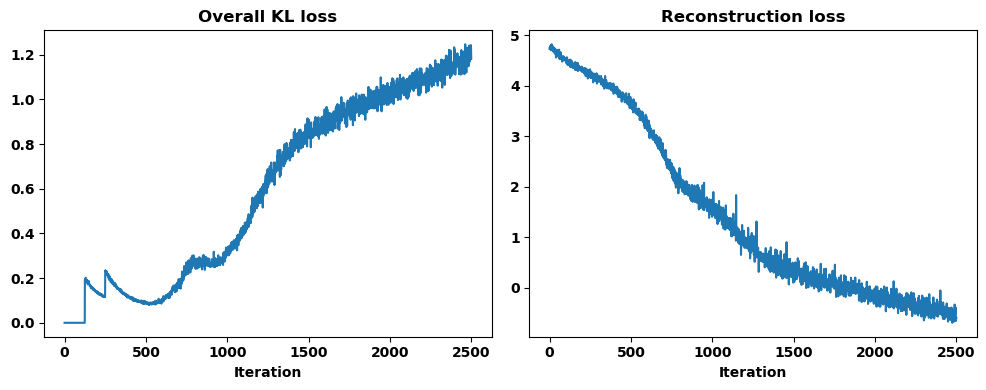

In [13]:
fig, axs = plt.subplots(nrows=1, ncols=2, sharex=True, figsize=(10, 4))

# Overall KL loss
axs[0].plot(kl_2)
axs[0].set_xlabel("Iteration")
axs[0].set_title("Overall KL loss")
# Reconstruction loss
axs[1].plot(recon_2)
axs[1].set_xlabel("Iteration")
axs[1].set_title("Reconstruction loss")
plt.tight_layout()

### Plot KL loss per hierarchy

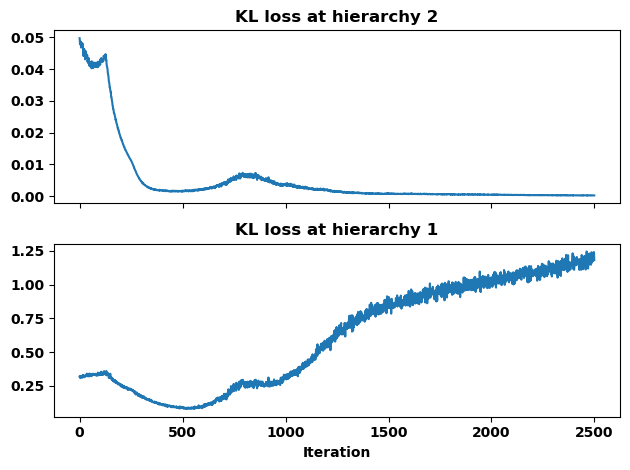

In [14]:
num_hier = kl_hier_2.shape[1]
fig, axs = plt.subplots(nrows=num_hier, ncols=1, sharex=True)

for i in range(num_hier):
    axs[i].plot(kl_hier_2[:, i], label="Level "+str(i))
    axs[i].set_title("KL loss at hierarchy " + str(num_hier-i))
axs[i].set_xlabel("Iteration")
plt.tight_layout()

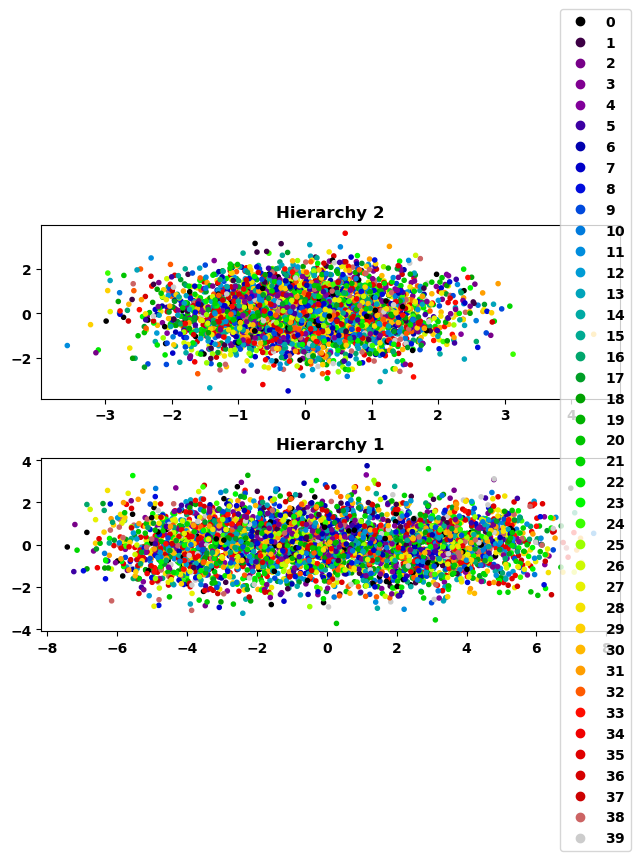

In [15]:
model_2.eval()
with torch.no_grad():
    for batch in test_loader:
        x, u = util.get_batch(batch, cfg['data_src'], device)
        output = model_2(x)
        
lbls = np.where(u.detach().cpu().numpy())[1]
zs = model_2.get_z_samples()
titles = ["Hierarchy 2", "Hierarchy 1"]
util.plot_multiple_pca(zs, lbls=lbls, title_lst=titles)